# Introduction to Python Project : FoodHub Data Analysis

### **Problem Statement**

##### *Write the problem statement and objectives here*

A food aggregator company, FoodHub is maintaining the number of restaurants in NewYork through an app. The number of restaurants are increasing day by day due to lot of students and busy professionals. The company has stored the data in online portal for the orders placed from the registered customers and need to analyze the data for customer experience, delivery efficiency and restaurant performance.

### **Objective**

As a data scientist, your objective is to analyze the data to get an idea about the demand of different restaurants which will help the FoodHub company in enhancing their customer experience to improve its business.

### Data Dictionary

Mention the data dictionary here

order_id: Unique ID of the order

customer_id: ID of the customer who ordered the food

restaurant_name: Name of the restaurant

cuisine_type: Cuisine ordered by the customer

cost_of_the_order: Cost of the order

day_of_the_week: Indicates whether the order is placed on a weekday or
weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

rating: Rating given by the customer out of 5

food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q

In [ ]:
# Write your code here to import necessary libraries for the project

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline
pd.set_option("display.float_format", lambda x: "%.2f" % x) #to display values upto 2 decimal places

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
df=pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 columns present in the dataset

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
4 columns has integer datatypes with non-null values

1 column has float datatype with non-null values

4 columns has object datatypes with non-null values

Need to convert "rating" column datatype from object to float as for some of the ratings are showing as "Not given".

In [ ]:
# Taking backup before converting object to float

df_original = df.copy()

#Now replacing "Not given" to NaN values in rating column

df['rating'] = df['rating'].replace("Not given", np.nan)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating']

,rating
0,NaN
1,NaN
2,5.00
3,3.00
4,4.00
...,...
1893,5.00
1894,5.00
1895,NaN
1896,5.00


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


#### Observations:
yes, there are 736 missing values found in rating column.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


In [ ]:
#2nd method to find the min, average and max values are shown below
fpt_min = print('Minimum food_preparation_time: ',df['food_preparation_time'].min())
fpt_average = print('Average food_preparation_time: ',df['food_preparation_time'].mean())
fpt_max = print('Max food_preparation_time: ',df['food_preparation_time'].max())

Minimum food_preparation_time:  20
Average food_preparation_time:  27.371970495258168
Max food_preparation_time:  35


#### Observations:
Min food preparation time : 20 min

Average food preparation time : 27 min

Max food preparation time: 35 min

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
df['rating'].isnull().sum()

np.int64(736)

#### Observations:
736 orders are not rated

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

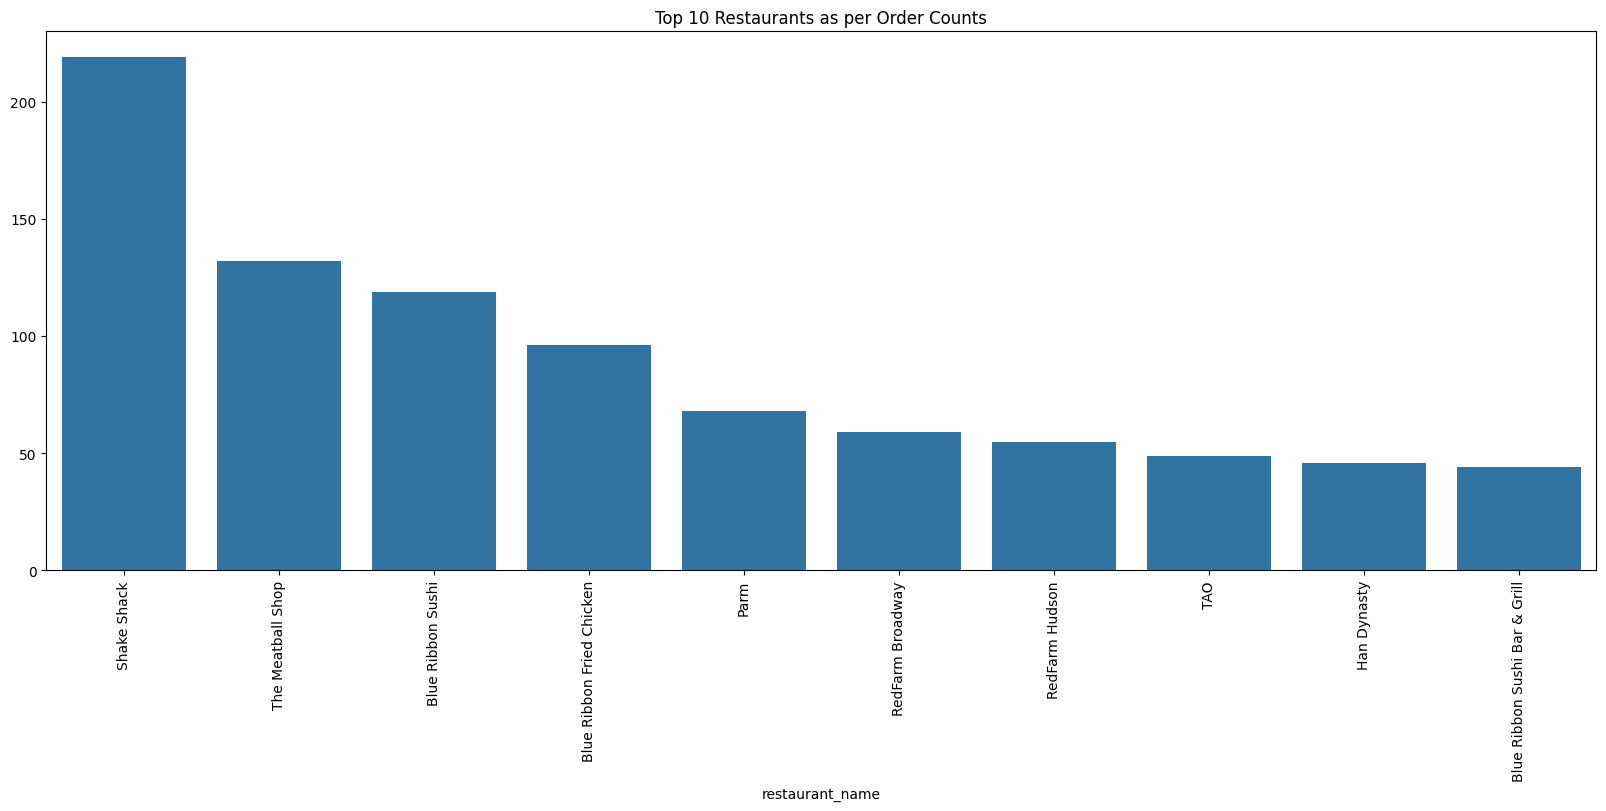

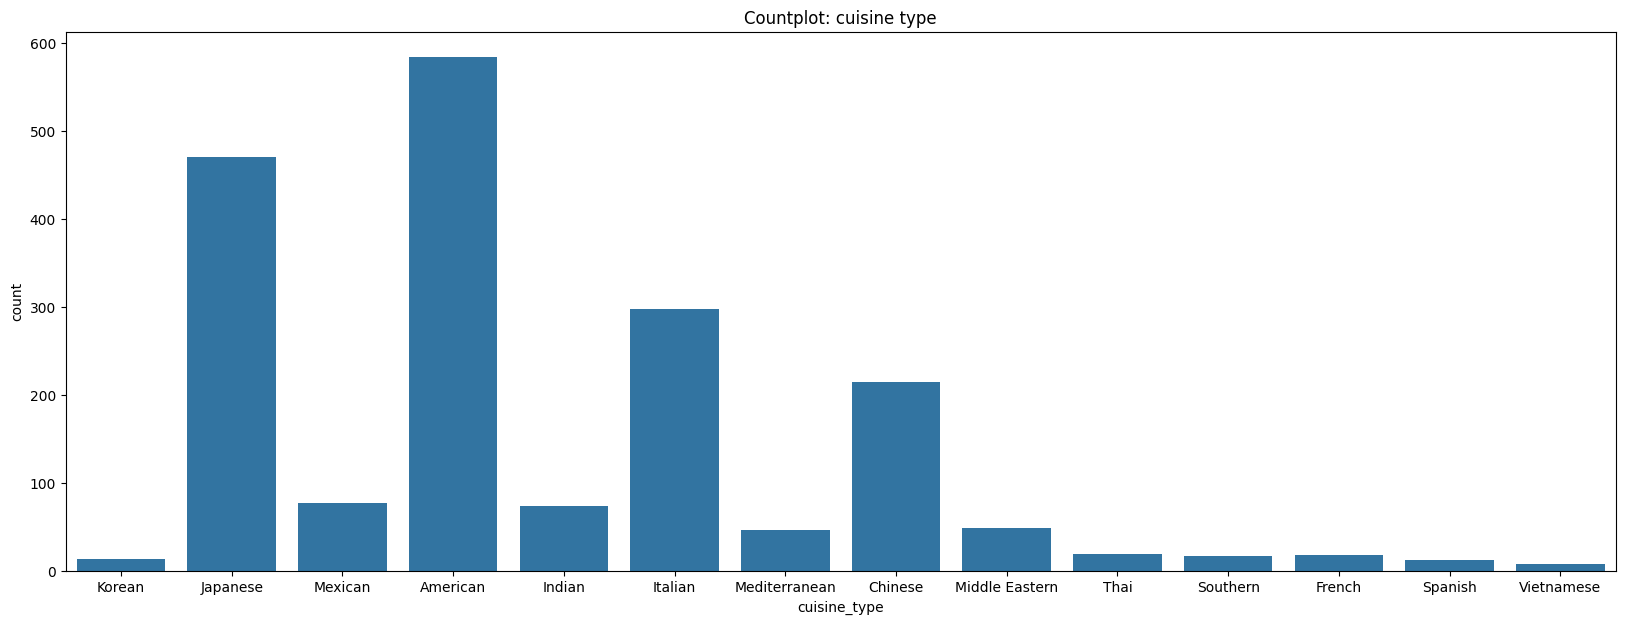

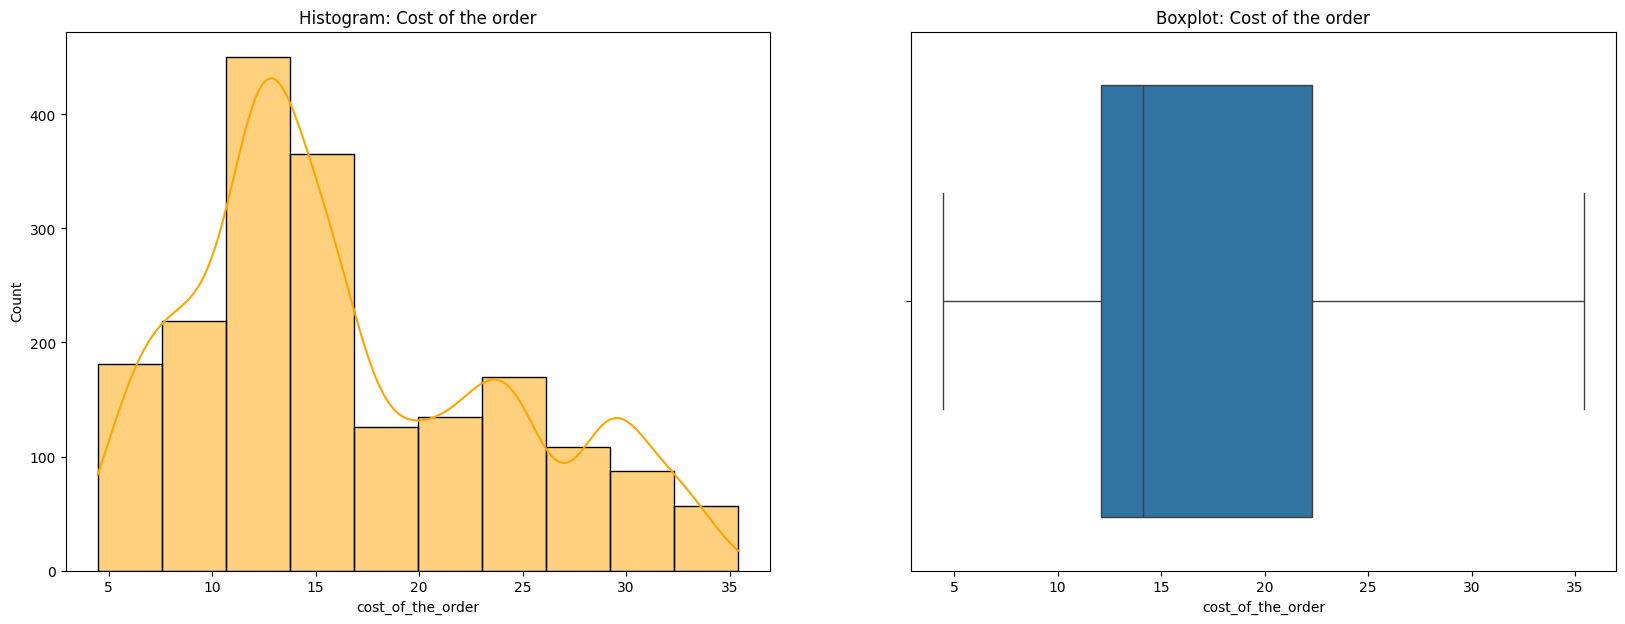

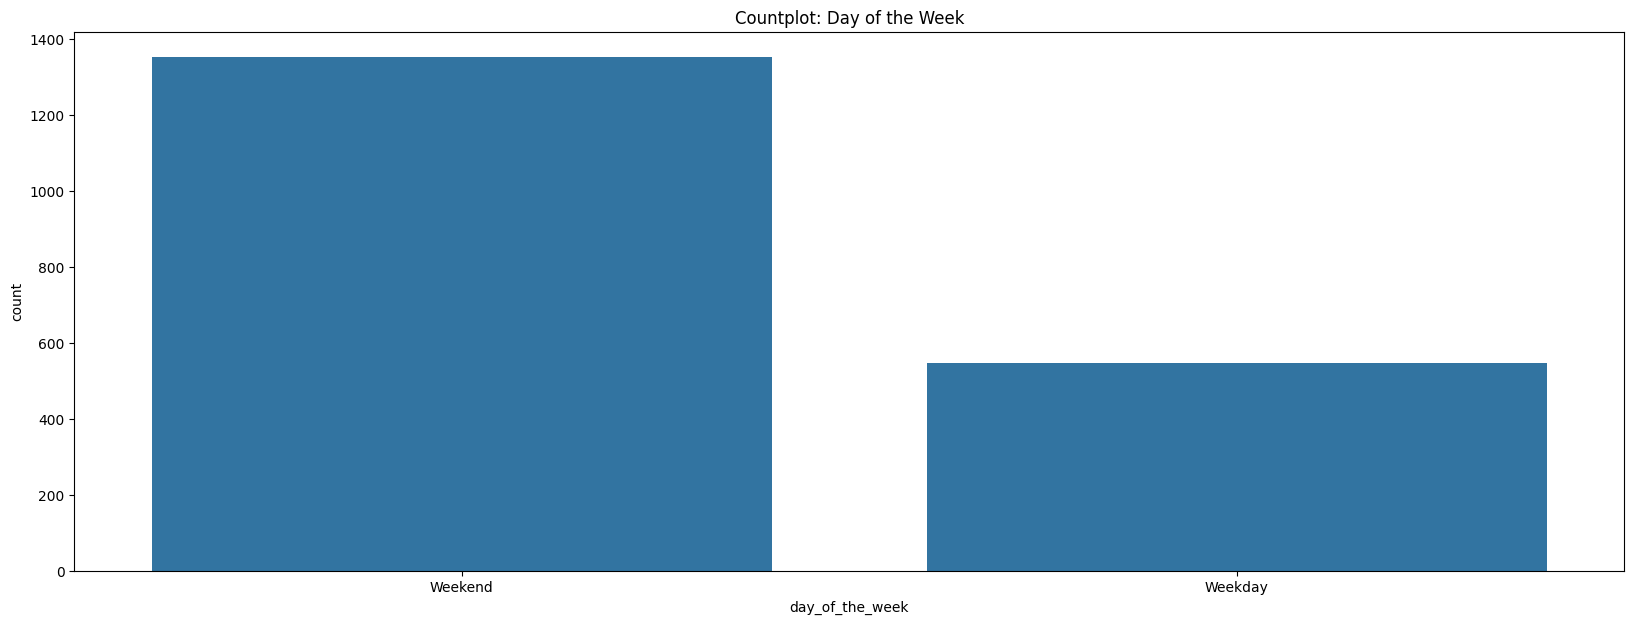

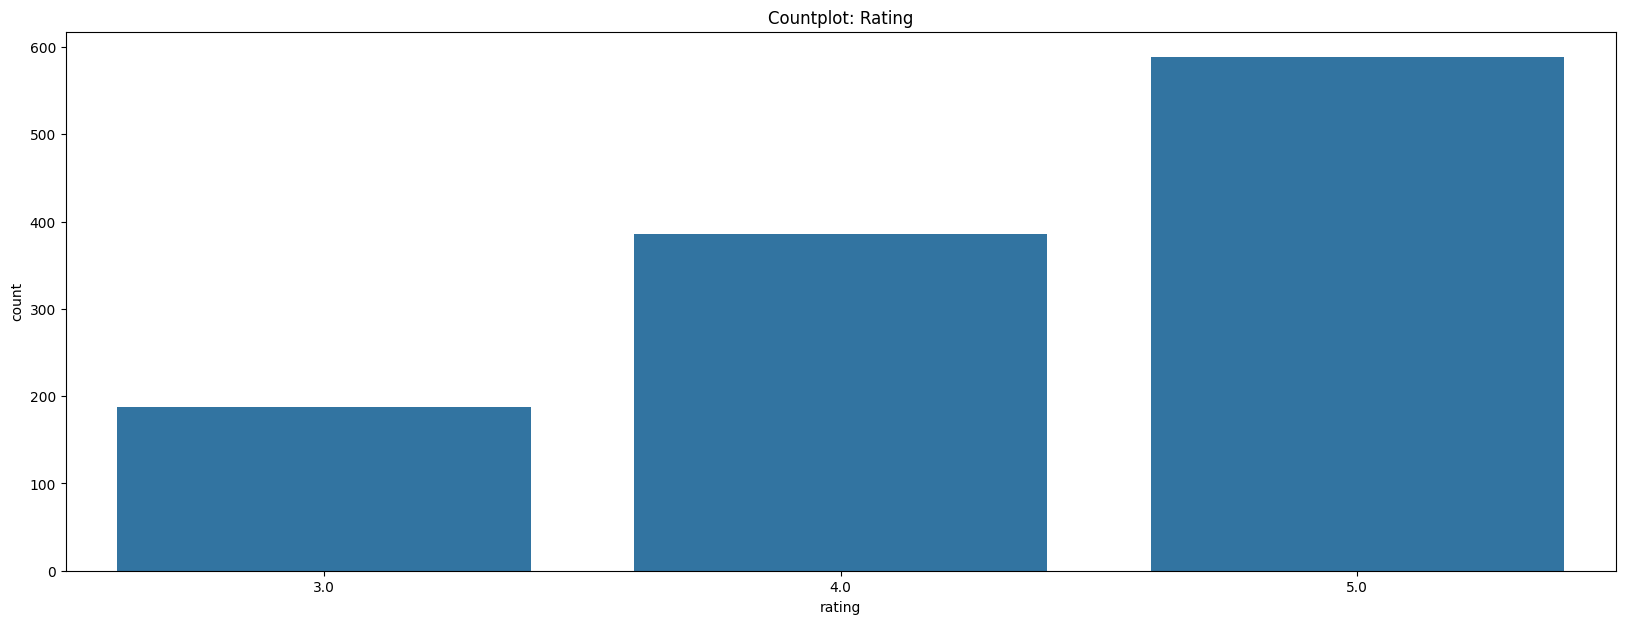

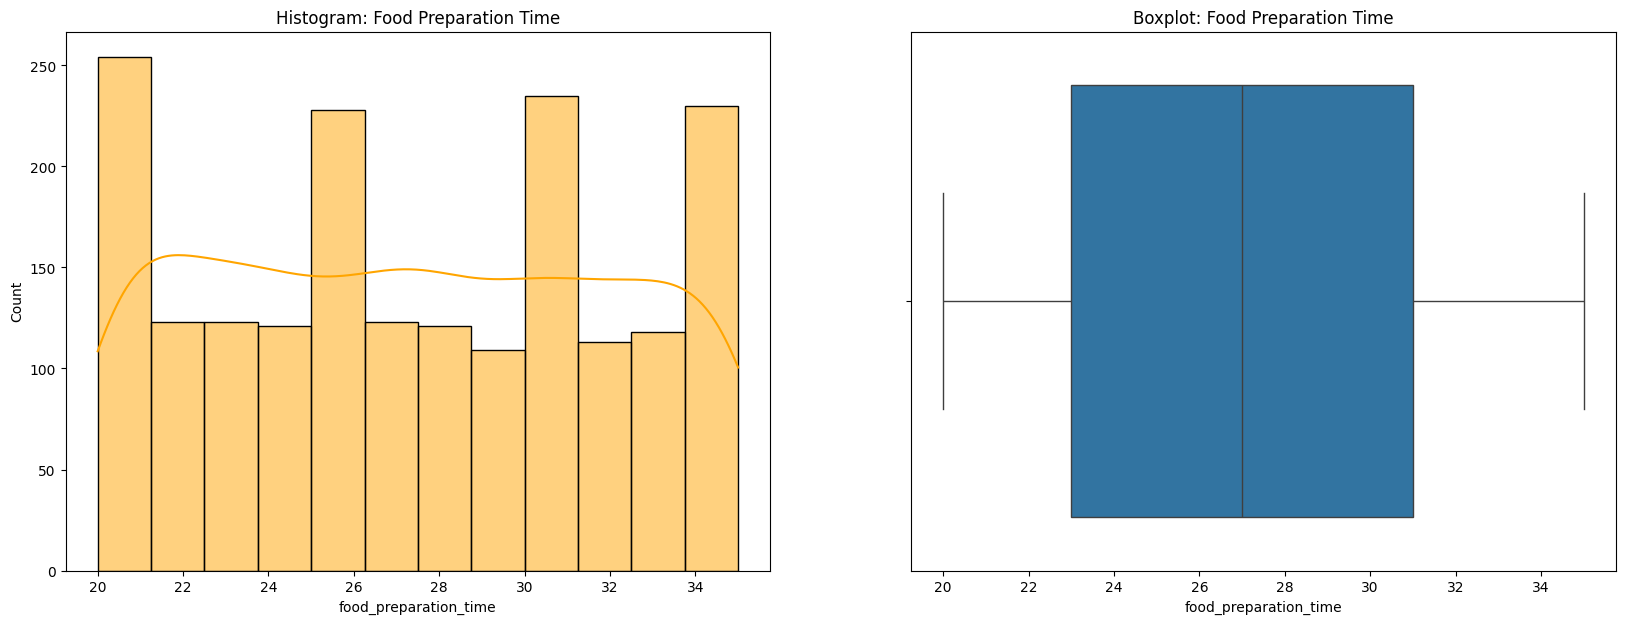

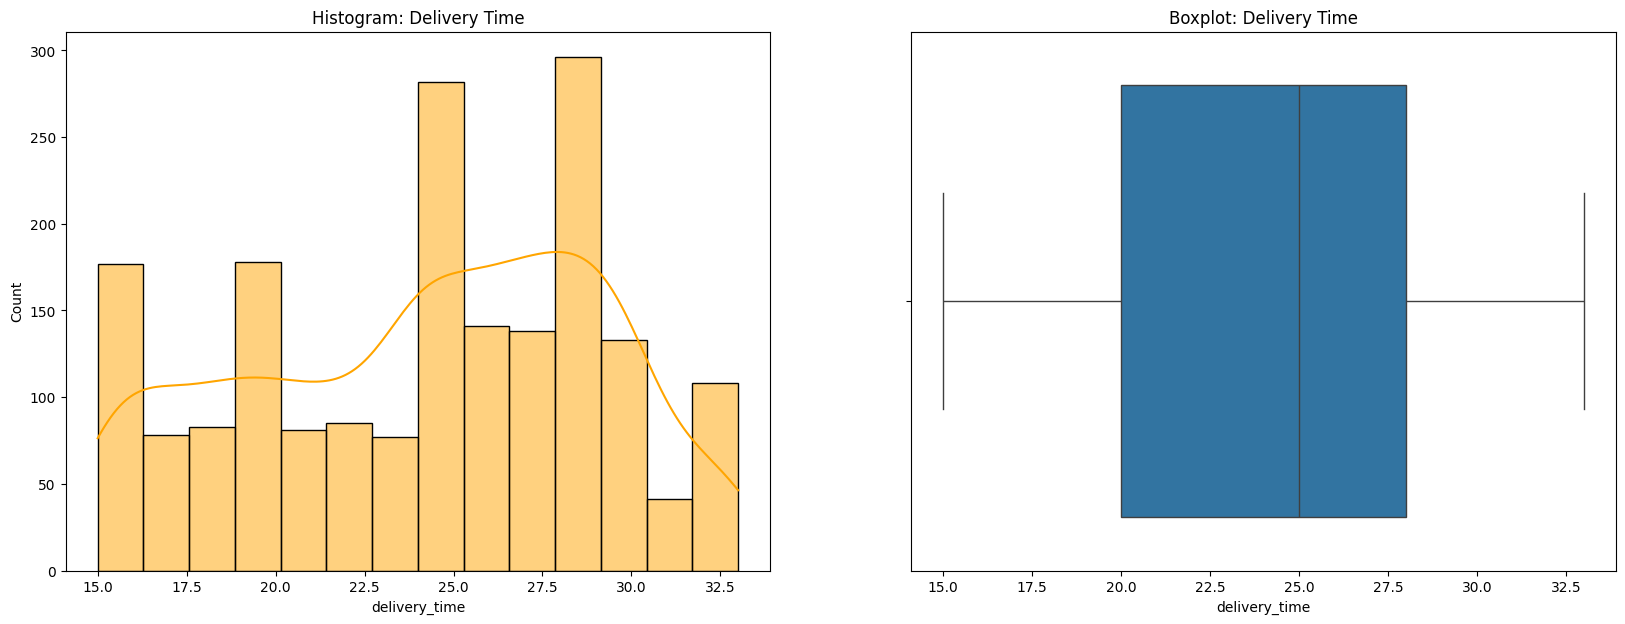

In [ ]:
# Write the code here

# 1. restaurant_name
# As this is categorical, bargraph will be used. All the restaurant names are clumsy in graph, hence considering only top10 restaurants.
top10_restaurants = df['restaurant_name'].value_counts().head(10)
top10_restaurants
plt.figure(figsize=(20,7))
sns.barplot(x=top10_restaurants.index, y=top10_restaurants.values)
plt.xticks(rotation=90)
plt.title("Top 10 Restaurants as per Order Counts")
plt.show()

# 2. cuisine_type
# As this is also categorical, we can use bargraph.
plt.figure(figsize=(20,7))
sns.countplot(data=df,x='cuisine_type');
plt.title("Countplot: cuisine type")
plt.show()

# 3. Cost_of_the_order
# As this is Numerical variable, we can use histogram and boxplot
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
plt.title("Histogram: Cost of the order")
sns.histplot(data=df, x='cost_of_the_order',color='orange',bins=10,kde=True);
# Boxplot
plt.subplot(1,2,2)
plt.title('Boxplot: Cost of the order')
sns.boxplot(data=df, x='cost_of_the_order');
plt.show()


# 4. day_of_the_week
# As this is categorical variable, we can use bargraph
plt.figure(figsize=(20,7))
sns.countplot(data=df,x='day_of_the_week')
plt.title("Countplot: Day of the Week")
plt.show()

# 5. Rating
# As this is categorical variable, we can use bargraph
plt.figure(figsize=(20,7))
sns.countplot(data=df,x='rating')
plt.title('Countplot: Rating')
plt.show()


# 6. food_preparation_time
# As this is numerical variable, we can use histogram and boxplots
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
plt.title("Histogram: Food Preparation Time")
sns.histplot(data=df, x='food_preparation_time',color='orange',kde=True);
# Boxplot
plt.subplot(1,2,2)
plt.title('Boxplot: Food Preparation Time')
sns.boxplot(data=df, x='food_preparation_time');
plt.show()


# 7. Delivery Time
# As this is numerical variable, we can use histogram and boxplots
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
plt.title("Histogram: Delivery Time")
sns.histplot(data=df, x='delivery_time',color='orange',kde=True);
# Boxplot
plt.subplot(1,2,2)
plt.title('Boxplot: Delivery Time')
sns.boxplot(data=df, x='delivery_time');
plt.show()


#### Observations:

1. Restaurant Name: From the Bargraph, in top 10 restaurants, Shake Shack has max orders than other restaurants approximately 200+ orders.

2. Cuisine Type: From the Bargraph, max customers preferred American cuisine approximately 570.

3. Cost of the Order: From the histogram graph, customers purchased the orders between 10 to 20 mostly and both the histogram and boxplot graphs are showing right skewed.

4. Day Of the Week: From the bargraph, there is a high demand in Weekends when compared to Weekdays.

5. Rating: From the bargraph, Customers given more 5 ratings when compared with 3 and 4 ratings.

6. Food Preparation Time: From both histogram and boxplots, Food preparation time app takes from 20min to 35min and average time is 27min

7. Delivery Time: From both histogram and boxplots, Delivery time takes approximately 15min to 32.5min and average time is 25min.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
top5_restaurants = df['restaurant_name'].value_counts().head(5)
top5_restaurants

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

Top 5 restaurants with number of orders received

Shake Shack               : 219

The Meatball Shop         : 132

Blue Ribbon Sushi         : 119

Blue Ribbon Fried Chicken : 96

Parm                      : 68

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
Weekend_cuisines = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()
print(Weekend_cuisines)


cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Middle Eastern     32
Mediterranean      32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64


#### Observations:
From the above output, most popular cuisine on weekends is American with 415 orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
df.head()
orders_more_than_20 = (df['cost_of_the_order'] > 20).sum()
print(orders_more_than_20)
Total_orders = len(df)
print(Total_orders)
Percentage_of_orders_more_than_20 = (orders_more_than_20 / Total_orders) * 100
print(Percentage_of_orders_more_than_20)

555
1898
29.24130663856691


#### Observations:

Percentage of the orders cost more than 20 dollars is 29.24%.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24


In [ ]:
mean_delivery_time = df['delivery_time'].mean()
print(mean_delivery_time)

24.161749209694417


#### Observations:
Mean order for delivery time is 24.16min

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24


In [ ]:
customer_orders_count = df['customer_id'].value_counts()
top_3_customers = customer_orders_count.head(3)
top_3_customers

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The customers with the above customer_ids are the 3 topmost customers who placed more orders and they are eligible for 20% discount vouchers.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


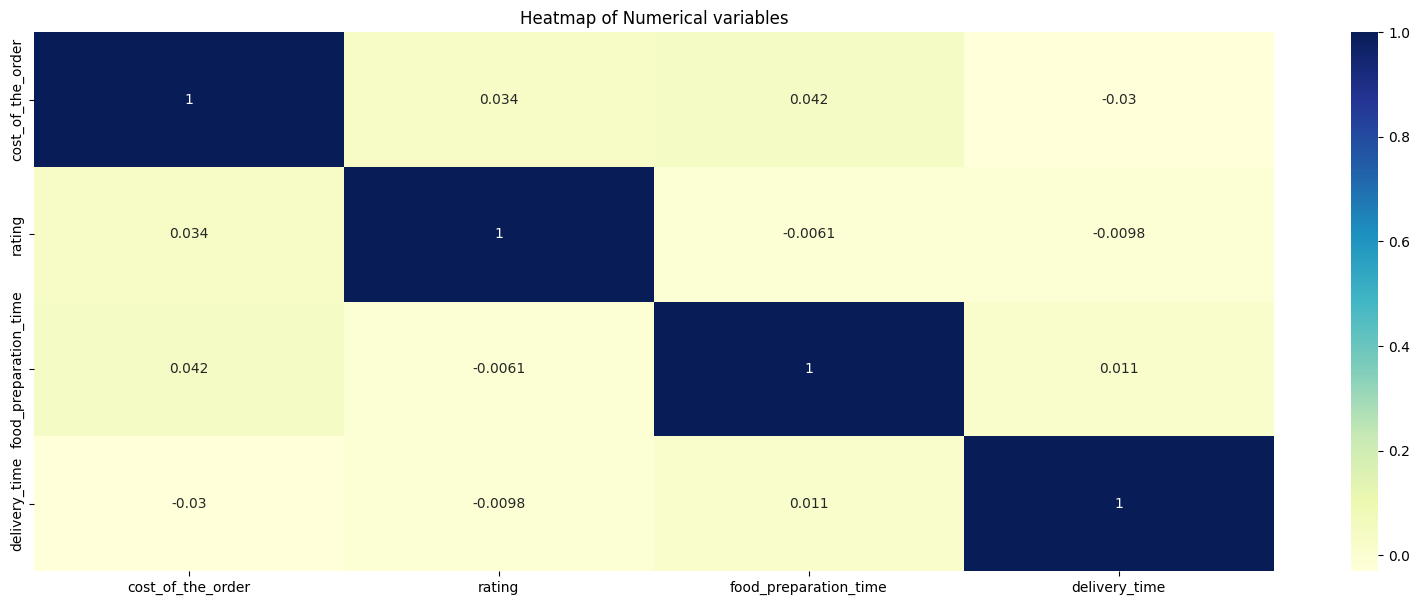

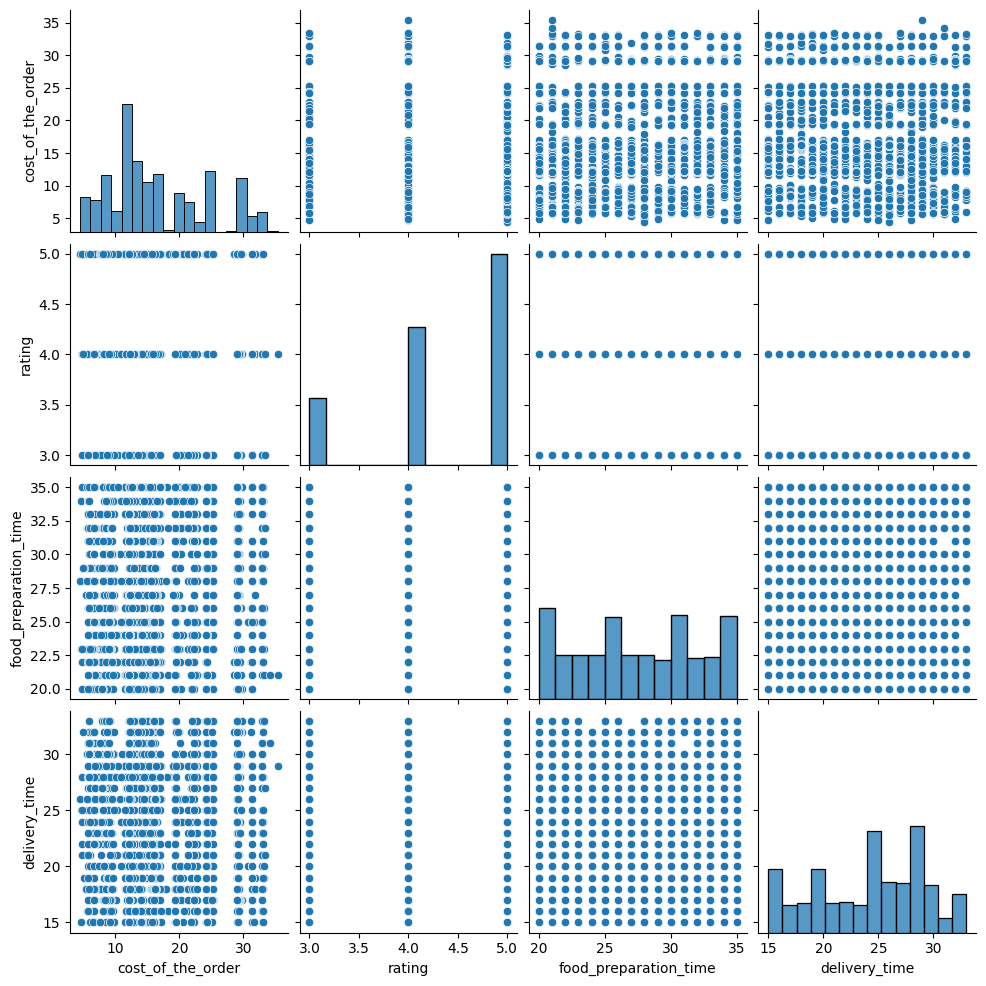

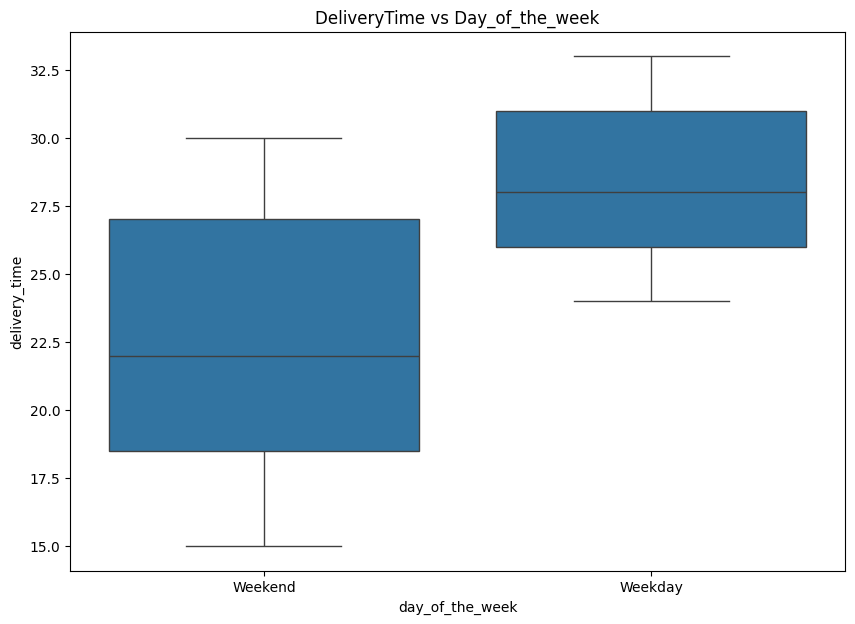

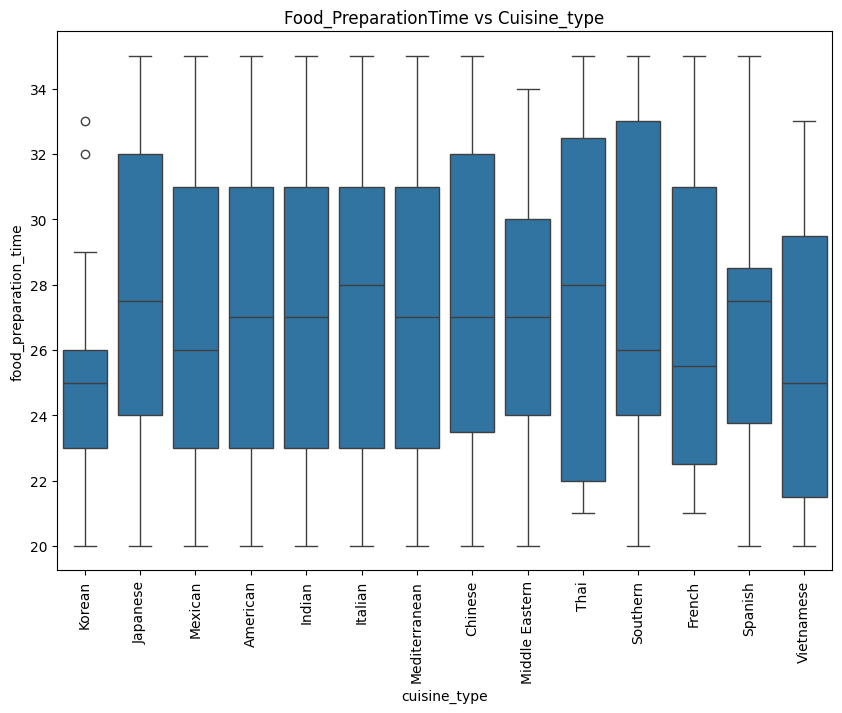

/tmp/ipython-input-4264581559.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="cuisine_type", y="rating", estimator="mean", ci=None)


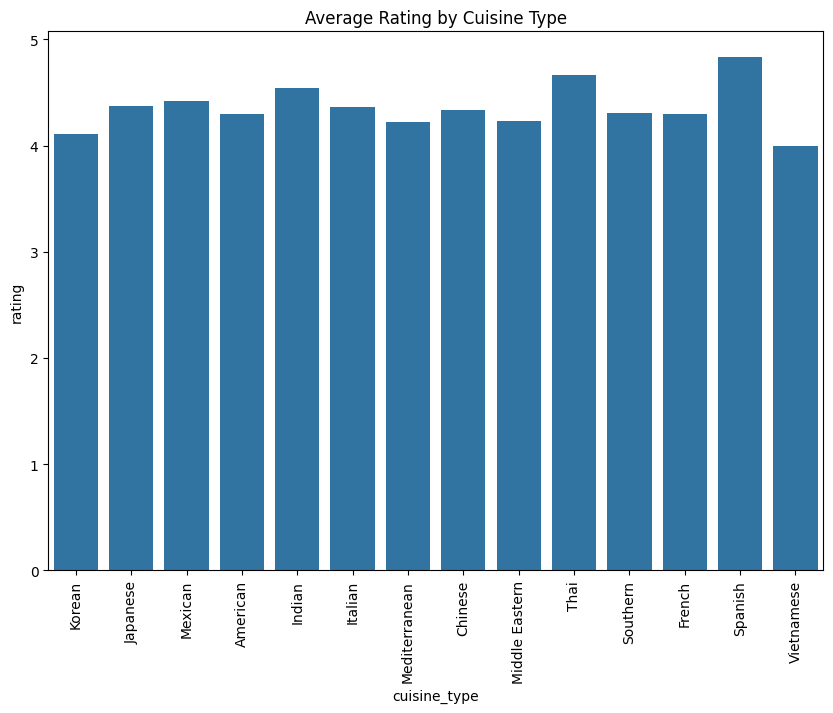

In [ ]:
# Write the code here
# Relations between numerical to numerical variables

# Heatmap
plt.figure(figsize=(20,7))
sns.heatmap(data=df[['cost_of_the_order','rating','food_preparation_time','delivery_time']].corr(), annot=True, cmap='YlGnBu');
plt.title('Heatmap of Numerical variables')
plt.show()

# Pairplot shows relationship between two numeric variables
sns.pairplot(data=df[['cost_of_the_order','rating','food_preparation_time','delivery_time']]);

# ----------------------------------------------------
# Relations between numerical to categorical variables

# delivery_time vs day_of_the_week
plt.figure(figsize=(10,7))
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time');
plt.title('DeliveryTime vs Day_of_the_week')
plt.show()

# food_preparation_time vs cuisine_type
plt.figure(figsize=(10,7))
sns.boxplot(data=df,x='cuisine_type',y='food_preparation_time');
plt.title('Food_PreparationTime vs Cuisine_type')
plt.xticks(rotation=90)
plt.show()

# Cuisine Type vs Rating
plt.figure(figsize=(10,7))
sns.barplot(data=df, x="cuisine_type", y="rating", estimator="mean", ci=None)
plt.xticks(rotation=90)
plt.title("Average Rating by Cuisine Type")
plt.show()


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
restaurants_fulfil = df.groupby('restaurant_name')['rating'].agg(['count', 'mean']).query('count > 50 and mean > 4')
restaurants_fulfil

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.33
Blue Ribbon Sushi,73,4.22
Shake Shack,133,4.28
The Meatball Shop,84,4.51


#### Observations:
The above 4 restaurants are eligible for promotional offer as they are having high rating count greater than 50 and average rating greater than 4.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
def revenue(cost):
  if cost > 20:
    return cost * (25/100)
  elif cost > 5:
    return cost * (5/100)
  else:
    return 0

df['revenue'] = df['cost_of_the_order'].apply(revenue)
net_revenue = df['revenue'].sum()
print('Net revenue generated by company: $',round(net_revenue, 2))

Net revenue generated by company: $ 4514.59


#### Observations:
1. Company charges 25% amount on the orders cost more than 20 dollars,
charges 15% amount on the orders from 5 dollars to 20 dollars and
no charges below the orders cost less than or equal to 5 dollars.
2. Net revenue generated by the company on orders is $4514.59

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
df['total_time_for_deliver'] = df['food_preparation_time'] + df['delivery_time']
#print(df['total_time_for_deliver'])
order_more_than_60_min = df[df['total_time_for_deliver'] > 60].shape[0]
print("Orders more than 60min: ",order_more_than_60_min)
total_orders = df.shape[0]
print('total orders: ',total_orders)
Percentage_of_orders_more_than_60 = (order_more_than_60_min / total_orders) * 100
#Percentage_of_orders_more_than_60
print("percentage of orders more than 60min: ",round(Percentage_of_orders_more_than_60,2))

Orders more than 60min:  200
total orders:  1898
percentage of orders more than 60min:  10.54


#### Observations:
Orders took more than 60min is 200

Total orders is 1898

Percentage of orders took more than 60min is 10.54%

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
df['day_type'] = df['day_of_the_week'].apply(lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')
mean_delivery_time = df.groupby('day_type')['delivery_time'].mean()
print(mean_delivery_time)


day_type
Weekday   24.16
Name: delivery_time, dtype: float64


#### Observations:
Weekday mean delivery time is 24.16 than weekends.

In Weekdays, delivery is faster when compared with weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Vietnamese cuisine_type has ratings less than 4
*  Delivery time in Weekends is slower than Weekdays
*  The restaurants having high rating count greater than 50 and average rating greater than 4 are eligible for promotional offers for advertising.
*  The most popular cuisine on weekends is American
*  Identified higher ratings for faster delivery and popular cuisines

### Recommendations:

*  Improve the quality of Vietnamese cuisine_type to increase the ratings
*  Try to improve Weekend deliveries. (Ex: increasing staff)
*  Provide adds for restaurants with more ratings and average rating greater than 4 to attract customers.
*  Provide priority service to customers to increase ratings.
*  Provide ads on orders more than $20 as the company gets 25% additional amount from restaurants.    